In [68]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated
from langchain.chat_models import init_chat_model
from langchain_core.messages import SystemMessage, HumanMessage
from dotenv import load_dotenv
import operator

load_dotenv()

True

In [69]:
generator_llm = init_chat_model("qwen/qwen3-32b", model_provider="groq", temperature=0.5, reasoning_format = 'hidden')
evaluator_llm = init_chat_model("llama-3.3-70b-versatile", model_provider="groq", temperature=0.5)
optimizer_llm = init_chat_model("qwen/qwen3-32b", model_provider="groq", temperature=0.5)

In [70]:
from pydantic import BaseModel, Field

class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")

In [71]:
structured_evaluator_llm = evaluator_llm.with_structured_output(TweetEvaluation)

In [72]:
class TweetState(TypedDict):
    topic: str
    tweet: str
    evaluation: Literal['approved', 'needs_improvement']
    feedback: str
    iteration: int
    max_iteration: int

    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

In [73]:
def generate_tweet(state: TweetState):
    #prompt
    messages = [
                SystemMessage(content="You are a funny and clever Twitter/X influencer."),
                HumanMessage(content=f"""
        Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

        Rules:
        - Do NOT use question-answer format.
        - Max 280 characters.
        - Use observational humor, irony, sarcasm, or cultural references.
        - Think in meme logic, punchlines, or relatable takes.
        - Use simple, day to day english
        """)
    ]

    # send generator llm
    response = generator_llm.invoke(messages).content

    return {'tweet': response, 'tweet_history': [response]}

In [74]:
def evaluate_tweet(state: TweetState):

    messages = [
            SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
            HumanMessage(content=f"""
        Evaluate the following tweet:

        Tweet: "{state['tweet']}"

        Use the criteria below to evaluate the tweet:

        1. Originality – Is this fresh, or have you seen it a hundred times before?  
        2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
        3. Punchiness – Is it short, sharp, and scroll-stopping?  
        4. Virality Potential – Would people retweet or share it?  
        5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

        Auto-reject if:
        - It's written in question-answer format (e.g., "Why did..." or "What happens when...")
        - It exceeds 280 characters
        - It reads like a traditional setup-punchline joke
        - Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

        ### Respond ONLY in structured format:
        - evaluation: "approved" or "needs_improvement"  
        - feedback: One paragraph explaining the strengths and weaknesses 
        """)
    ]

    response = structured_evaluator_llm.invoke(messages)

    return {'evaluation': response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}

In [75]:
def optimise_tweet(state: TweetState):

    messages = [
                SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
                HumanMessage(content=f"""
        Improve the tweet based on this feedback:
        "{state['feedback']}"

        Topic: "{state['topic']}"
        Original Tweet:
        {state['tweet']}

        Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
        """)
    ]

    response = optimizer_llm.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'tweet': response, 'iteration': iteration,  'tweet_history': [response]}

In [76]:
def route_evaluation(state: TweetState):

    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement'

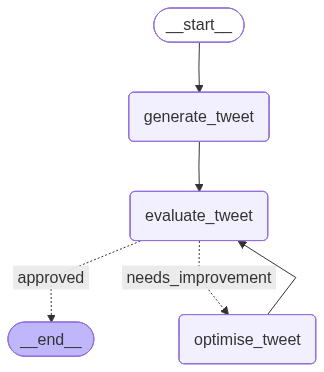

In [77]:
graph = StateGraph(TweetState)

graph.add_node('generate_tweet', generate_tweet)
graph.add_node('evaluate_tweet', evaluate_tweet)
graph.add_node('optimise_tweet', optimise_tweet)

graph.add_edge(START, 'generate_tweet')
graph.add_edge('generate_tweet', 'evaluate_tweet')
graph.add_conditional_edges('evaluate_tweet', route_evaluation, {'approved': END, 'needs_improvement': 'optimise_tweet'})
graph.add_edge('optimise_tweet', 'evaluate_tweet')

workflow = graph.compile()
workflow

In [84]:
initial_state = {
    "topic": "sdfsdaf",
    "iteration": 1,
    "max_iteration": 5
}
result = workflow.invoke(initial_state)

In [85]:
result

{'topic': 'sdfsdaf',
 'tweet': '"sdfsdaf is what my keyboard types when I ask it to send a love note but it\'s secretly writing a haiku about its hatred for me. We all have our talents."  \n\n*(279 chars, meme logic + relatable tech pettiness)*',
 'evaluation': 'approved',
 'feedback': "This tweet is a masterclass in humor, originality, and punchiness. The idea of a keyboard secretly writing a haiku about its hatred for the user is fresh and unique, making it stand out from the usual tech-related complaints. The tweet's format is also well-executed, with a clear and concise narrative that doesn't rely on tired joke structures. The use of relatable tech pettiness and meme logic adds to the tweet's virality potential, making it likely to resonate with a wide audience. Overall, this tweet is a well-crafted, scroll-stopping gem that effectively balances humor, originality, and brevity.",
 'iteration': 1,
 'max_iteration': 5,
 'tweet_history': ['"sdfsdaf is what my keyboard types when I ask

In [86]:
for tweet in result['tweet_history']:
    print(tweet)

"sdfsdaf is what my keyboard types when I ask it to send a love note but it's secretly writing a haiku about its hatred for me. We all have our talents."  

*(279 chars, meme logic + relatable tech pettiness)*
